<a href="https://colab.research.google.com/github/liuyf03/dreamydoodle.github.io/blob/main/reddit_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install dependencies and set up environment

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Install pyarrow to handle parquet files
!pip install google-generativeai scikit-learn spacy pandas pyarrow
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 66.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
import json
import time
import pandas as pd
import os

In [5]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# Load data and conduct preliminary analysis

In [6]:
import pandas as pd

# Define the path to your file in Google Drive
file_path = '/content/drive/MyDrive/Reddit/reddit_data.parquet'

# Load the data into a pandas DataFrame
df = pd.read_parquet(file_path)


In [7]:
# Print the shape of the DataFrame (rows, columns)
print(f"DataFrame shape: {df.shape}")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the data:")
display(df.head())

# Get a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame shape: (495203, 9)

First 5 rows of the data:


,id,subreddit,title,selftext,score,num_comments,created_utc,url,top_comments
0,1cugjnw,Home,My parents bought the house 6 months ago after...,Any idea for next steps and what their options...,19112,5780,1.715981e+09,https://www.reddit.com/gallery/1cugjnw,[]
1,1fuzc49,Home,What is this stuff coming out from my balls?,I’ve noticed something strange in my garage—st...,8186,1624,1.727928e+09,https://www.reddit.com/gallery/1fuzc49,[]
2,1hnjl52,Home,Noticed this today on the main door. Did someb...,,4052,521,1.735319e+09,https://www.reddit.com/gallery/1hnjl52,[]
3,1f2r3as,Home,"$16,000 for 8 Pella windows. Would you be ok w...",,3559,1735,1.724790e+09,https://www.reddit.com/gallery/1f2r3as,[]
4,1hbgl4j,Home,Is this a problem? I think my house is shifting…,"There’s a couple doorways that are like this, ...",2382,1764,1.733876e+09,https://i.redd.it/5tswmvu6446e1.jpeg,[]



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495203 entries, 0 to 495202
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            495203 non-null  object 
 1   subreddit     495203 non-null  object 
 2   title         495203 non-null  object 
 3   selftext      495203 non-null  object 
 4   score         495203 non-null  int64  
 5   num_comments  495203 non-null  int64  
 6   created_utc   495203 non-null  float64
 7   url           495203 non-null  object 
 8   top_comments  495203 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 34.0+ MB


In [5]:
print("Statistical summary of numerical columns:")
display(df[['score', 'num_comments']].describe())


Statistical summary of numerical columns:


,score,num_comments
count,495203.000000,495203.000000
mean,3735.383332,272.475902
std,9062.651370,654.180630
min,0.000000,0.000000
25%,301.000000,52.000000
50%,1039.000000,117.000000
75%,3129.000000,267.000000
max,273480.000000,54292.000000


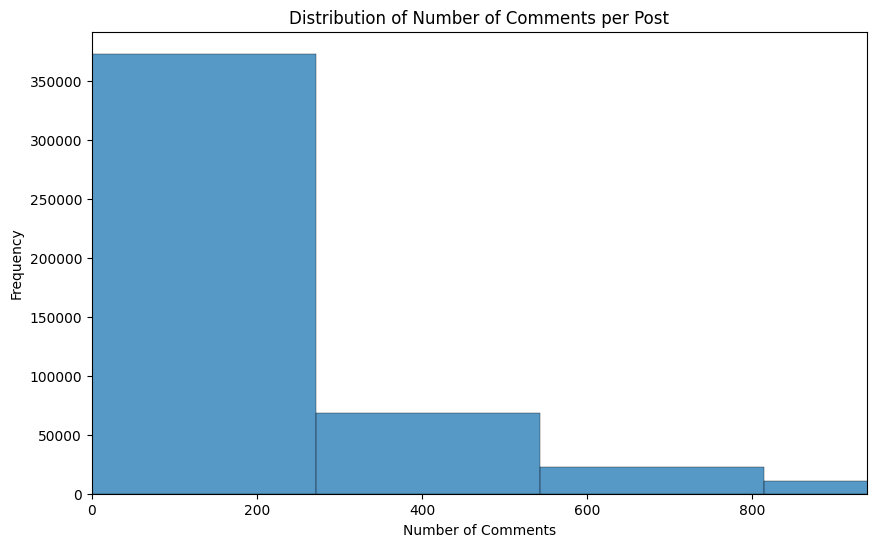

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['num_comments'], bins=200, kde=False)
plt.title('Distribution of Number of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Frequency')
plt.xlim(0, df['num_comments'].quantile(0.95)) # Limit x-axis to the 99th percentile for better visualization
plt.show()

In [12]:
print("Top 100 most-commented-on posts:")
most_commented_posts = df.nlargest(100, 'num_comments')[['title', 'subreddit', 'score', 'num_comments']]
display(most_commented_posts)


Top 100 most-commented-on posts:


,title,subreddit,score,num_comments
458074,⚡️⚡️⚡️⚡️⚡️ 2024 US ELECTION THUNDERDOME⚡️⚡️⚡️⚡️⚡️,neoliberal,3739,54292
12000,Megathread: Former US President Donald Trump C...,politics,89554,41975
279940,[Game Thread] Georgia @ Alabama (7:30 PM ET),CFB,2147,39782
515,"Which show starts as a 10/10, but ends as a 1/10?",AskReddit,18300,37560
175209,What shall I name my baby based on his scan,notinteresting,83578,33492
...,...,...,...,...
710,People who get told they look younger than the...,AskReddit,9386,15500
742,Who is the rudest celeb you have met? What hap...,AskReddit,8633,15470
517,What illegal thing do you do on a regular basis?,AskReddit,18013,15469
121701,Salvation's Edge - The Final Shape Raid Race M...,DestinyTheGame,1257,15433


In [13]:
print("Top 10 subreddits by total score:")
top_subreddits_by_score = df.groupby('subreddit')['score'].sum().nlargest(10)
display(top_subreddits_by_score)


Top 10 subreddits by total score:


,score
subreddit,
pics,38965202
interestingasfuck,36008818
MadeMeSmile,34774610
Damnthatsinteresting,27120725
meirl,26280724
clevercomebacks,26076384
mildlyinfuriating,25967434
nextfuckinglevel,24909793
MurderedByWords,23855205


# Semantic analysis

## Genimi Credential

In [8]:
import google.generativeai as genai
from google.colab import userdata

In [9]:
# Load the API key from Colab secrets
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

## Analytics

In [10]:
# Create a new dataframe with concatenated 'title' and 'selftext' as 'text' column
df_text = df.copy()
df_text['text'] = df_text['title'] + ' ' + df_text['selftext'].fillna('')

# Remove the specified columns
df_text = df_text.drop(columns=['created_utc', 'url', 'top_comments'])

# Display the first few rows of the new DataFrame
display(df_text.head())

,id,subreddit,title,selftext,score,num_comments,text
0,1cugjnw,Home,My parents bought the house 6 months ago after...,Any idea for next steps and what their options...,19112,5780,My parents bought the house 6 months ago after...
1,1fuzc49,Home,What is this stuff coming out from my balls?,I’ve noticed something strange in my garage—st...,8186,1624,What is this stuff coming out from my balls? I...
2,1hnjl52,Home,Noticed this today on the main door. Did someb...,,4052,521,Noticed this today on the main door. Did someb...
3,1f2r3as,Home,"$16,000 for 8 Pella windows. Would you be ok w...",,3559,1735,"$16,000 for 8 Pella windows. Would you be ok w..."
4,1hbgl4j,Home,Is this a problem? I think my house is shifting…,"There’s a couple doorways that are like this, ...",2382,1764,Is this a problem? I think my house is shiftin...


In [18]:

DRY_RUN_NUM_ROWS = 30
# Gemini 2.5 Flash cost
INPUT_COST_PER_MILLION_TOKEN = 0.3
OUTPUT_COST_PER_MILLION_TOKEN = 2.5
# https://ai.google.dev/gemini-api/docs/pricing
def get_subreddit_summary(subreddit_name, subreddit_df, topk_post_to_process, model, dry_run=True):
    """Generates a summary for a subreddit using the Gemini API.
       When dry_run=True, calculate cost on a small sample of data"""

    # Select top posts by score for the summary
    sample_posts = subreddit_df.nlargest(topk_post_to_process, 'score')

    cost_scaling = len(sample_posts) / DRY_RUN_NUM_ROWS
    if dry_run:
        sample_posts = sample_posts.head(DRY_RUN_NUM_ROWS)

    total_input_tokens = 0
    total_output_tokens = 0

    # Concatenate post content for the prompt
    content = ""
    for _, post in sample_posts.iterrows():
        content += f"{post['text']}\n---\n"

    prompt = f"""
    You are an expert community analyst. Based on the following top posts from the subreddit named '/r/{subreddit_name}', provide a structured analysis in JSON format.

    Analyze the content and identify the community's niche, primary interests, and common challenges.

    Posts:
    \"\"\"
    {content}
    \"\"\"

    Provide the output as a single JSON object with the following keys, and limit the output :
    - "niche_description": " A one-paragraph summary of the community's specific focus (Under 200 words)",
    - "top_interests": ["A list of 3-5 key topics or subjects. (The entire list should be under 200 words in total)"],
    - "common_challenges": ["A list of 2-3 common problems or questions. (The entire list should be under 200 words in total)"],
    - "community_tone": "Describe the typical tone of the community. (Under 100 words)"
    """
    total_input_tokens += model.count_tokens(prompt).total_tokens
    try:
        response = model.generate_content(prompt)
        # Clean up the response to extract the JSON object
        json_response = json.loads(response.text.strip().replace('```json', '').replace('```', ''))
        total_output_tokens += model.count_tokens(response.text).total_tokens
        total_cost_est = cost_scaling * (total_input_tokens * INPUT_COST_PER_MILLION_TOKEN + total_output_tokens * OUTPUT_COST_PER_MILLION_TOKEN) / 1000000
        print(f"Estimated cost per subreddit: ${total_cost_est:.4f}")
        time.sleep(1)
        return json_response
    except Exception as e:
        print(f"An error occurred for /r/{subreddit_name}: {e}")
        return None



In [12]:

# Load the spaCy model
nlp = spacy.load('en_core_web_sm')

def extract_keywords_and_entities(subreddit_df, topk_post_to_process, max_char_to_process=100000):
    """Extracts TF-IDF keywords and named entities from a subreddit's posts."""
    sample_posts = subreddit_df.nlargest(topk_post_to_process, 'score')
    full_text = " ".join(sample_posts['text'])

    # 1. Keyword Extraction (TF-IDF)
    try:
        vectorizer = TfidfVectorizer(max_features=10, stop_words='english', ngram_range=(1,2))
        vectorizer.fit_transform([full_text])
        keywords = vectorizer.get_feature_names_out()
    except ValueError:
        keywords = [] # Handle cases with very little text

    # 2. Named Entity Extraction (NER)
    doc = nlp(full_text[:max_char_to_process]) # Process first 100k chars for efficiency
    entities = {
        ent.text.strip(): ent.label_
        for ent in doc.ents
        if ent.label_ in ['PERSON', 'ORG', 'GPE', 'PRODUCT', 'WORK_OF_ART'] and len(ent.text.strip()) > 3
    }
    # Get unique entities
    unique_entities = list(dict.fromkeys(entities))[:10]

    return {"keywords": list(keywords), "entities": unique_entities}

In [19]:

TOP_K_POST_TO_PROCESS_LLM = 50
TOP_K_POST_TO_PROCESS_KEYWORD = 500
def process_subreddit(name):
  subreddit = df_text[df_text['subreddit'] == name]
  summary_data = get_subreddit_summary(name, subreddit, TOP_K_POST_TO_PROCESS_LLM, llm, dry_run=False)
  metadata = extract_keywords_and_entities(subreddit, TOP_K_POST_TO_PROCESS_KEYWORD)

  if summary_data:
    # Combine all results
    combined_result = {
        "subreddit": name,
        **summary_data,
        **metadata
    }
    return combined_result

  return None

In [14]:
llm = genai.GenerativeModel('gemini-2.5-flash')

In [15]:
# Mount your Google Drive first
drive_path = '/content/drive/My Drive/Reddit/'
checkpoint_file = os.path.join(drive_path, 'knowledge_base_checkpoint.csv')

In [16]:
# Group the DataFrame by 'subreddit' and iterate through the groups
subreddit_groups = list(df_text.groupby('subreddit'))

In [ ]:
# Load previous results if they exist
file_exists = os.path.exists(checkpoint_file)
if file_exists:
  knowledge_base_df = pd.read_csv(checkpoint_file)
  processed_subs = knowledge_base_df['subreddit'].tolist()
else:
  knowledge_base_df = pd.DataFrame()
  processed_subs = []


new_results_to_csv = pd.DataFrame()
for name, group in subreddit_groups[:200]:
  if name in processed_subs:
    print(f"Skipping /r/{name}, already processed.")
    continue
  print(f"Processing subreddit: {name}")
  combined_result = process_subreddit(name)
  if combined_result:
    new_result_df = pd.DataFrame([combined_result])
    new_results_to_csv = pd.concat([new_results_to_csv, new_result_df], ignore_index=True)
    knowledge_base_df = pd.concat([knowledge_base_df, new_result_df], ignore_index=True)

  # Save progress after every 5 subreddits
  if len(new_results_to_csv) == 5:
    print(f"--- Saving checkpoint with {len(new_results_to_csv)} subs processed ---")
    new_results_to_csv.to_csv(
      checkpoint_file,
      mode='a', # Append mode
      header=not file_exists, # Write header only if file is new
      index=False
    )
    new_results_to_csv = pd.DataFrame()

# Save the final result at the end
if len(new_results_to_csv) > 0:
  print(f"--- Saving checkpoint with {len(new_results_to_csv)} subs processed ---")
  new_results_to_csv.to_csv(
      checkpoint_file,
      mode='a', # Append mode
      header=not file_exists, # Write header only if file is new
      index=False
  )

Skipping /r/196, already processed.
Skipping /r/2007scape, already processed.
Skipping /r/2westerneurope4u, already processed.
Skipping /r/30PlusSkinCare, already processed.
Skipping /r/3Dprinting, already processed.
Skipping /r/3d6, already processed.
Skipping /r/40kLore, already processed.
Skipping /r/49ers, already processed.
Skipping /r/4chan, already processed.
Skipping /r/ADHD, already processed.
Skipping /r/AITAH, already processed.
Skipping /r/AMA, already processed.
Skipping /r/AMDHelp, already processed.
Skipping /r/ARK, already processed.
Skipping /r/ASUS, already processed.
Skipping /r/ATBGE, already processed.
Skipping /r/AbruptChaos, already processed.
Skipping /r/Accounting, already processed.
Skipping /r/ActualPublicFreakouts, already processed.
Skipping /r/Adulting, already processed.
Skipping /r/Advice, already processed.
Skipping /r/AfterEffects, already processed.
Skipping /r/AirForce, already processed.
Skipping /r/AlienBodies, already processed.
Skipping /r/AmIThe

In [92]:

print(f"--- Saving checkpoint with {len(knowledge_base_df)} subs processed ---")
knowledge_base_df.to_csv(checkpoint_file, index=False)

--- Saving checkpoint with 19 subs processed ---
